# **Teeth Classification using Transfer Learning (MobileNetV2)**

In [1]:
import zipfile
import os

zip_path = "/content/Teeth DataSet.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(os.listdir("/content/"))

['.config', 'Teeth DataSet.zip', 'Teeth_Dataset', 'sample_data']


## **1. Importing Libraries**

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, Input, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import confusion_matrix
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns

## **2. Preprocessing(Normalization, Augmentation)**

In [3]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

train_dir = "/content/Teeth_Dataset/Training"
val_dir   = "/content/Teeth_Dataset/Validation"
test_dir  = "/content/Teeth_Dataset/Testing"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
# Data preprocessing for validation & testing
val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Flow images from directories
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    seed=SEED
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 3087 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.


## **3. Model Architecture (Transfer Learning with MobileNetV2)**
- Base model: MobileNetV2 (pretrained on ImageNet, frozen).
- Global Average Pooling.
- Dense layers for classification.

In [4]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,587,719 (9.87 MB)

 Trainable params: 329,735 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## **4. Callbacks**

In [5]:
checkpoint = ModelCheckpoint(
    filepath="best_teeth_model.h5",
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

## **5. Training the Model**

In [6]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=100,
    callbacks=checkpoint
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step - accuracy: 0.4969 - loss: 1.4263
Epoch 1: val_accuracy improved from -inf to 0.75584, saving model to best_teeth_model.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 81s 663ms/step - accuracy: 0.4979 - loss: 1.4233 - val_accuracy: 0.7558 - val_loss: 0.6829
Epoch 2/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.7164 - loss: 0.7787
Epoch 2: val_accuracy improved from 0.75584 to 0.78988, saving model to best_teeth_model.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 402ms/step - accuracy: 0.7165 - loss: 0.7788 - val_accuracy: 0.7899 - val_loss: 0.6040
Epoch 3/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.7735 - loss: 0.6263
Epoch 3: val_accuracy improved from 0.78988 to 0.87451, saving model to best_teeth_model.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 420ms/step - accuracy: 0.7737 - loss: 0.6260 - val_accuracy: 0.8745 - val_loss: 0.3910
Epoch 4/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 382ms/step - accuracy: 0.8235 - loss: 0.4992
Epoch 4: val_accuracy improved from 0.87451 to 0.89494, saving model to best_teeth_model.h5


...

97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 408ms/step - accuracy: 0.9593 - loss: 0.1304 - val_accuracy: 0.9864 - val_loss: 0.0609
Epoch 19/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9604 - loss: 0.1184
Epoch 19: val_accuracy did not improve from 0.98638
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 412ms/step - accuracy: 0.9604 - loss: 0.1184 - val_accuracy: 0.9796 - val_loss: 0.0702
Epoch 20/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.9577 - loss: 0.1364
Epoch 20: val_accuracy did not improve from 0.98638
97/97 ━━━━━━━━━━━━━━━━━━━━ 42s 439ms/step - accuracy: 0.9578 - loss: 0.1362 - val_accuracy: 0.9796 - val_loss: 0.0719
Epoch 21/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.9653 - loss: 0.0992
Epoch 21: val_accuracy did not improve from 0.98638
97/97 ━━━━━━━━━━━━━━━━━━━━ 42s 427ms/step - accuracy: 0.9652 - loss: 0.0993 - val_accuracy: 0.9718 - val_loss: 0.0801
Epoch 22/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - accuracy: 0.9632 - loss: 0.1098
Epoch 22: val_accura

97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 414ms/step - accuracy: 0.9689 - loss: 0.0810 - val_accuracy: 0.9874 - val_loss: 0.0426
Epoch 31/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9653 - loss: 0.0875
Epoch 31: val_accuracy did not improve from 0.98735
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 402ms/step - accuracy: 0.9653 - loss: 0.0875 - val_accuracy: 0.9815 - val_loss: 0.0528
Epoch 32/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9735 - loss: 0.0813
Epoch 32: val_accuracy did not improve from 0.98735
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 401ms/step - accuracy: 0.9735 - loss: 0.0814 - val_accuracy: 0.9767 - val_loss: 0.0589
Epoch 33/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9687 - loss: 0.0886
Epoch 33: val_accuracy improved from 0.98735 to 0.98833, saving model to best_teeth_model.h5


97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 406ms/step - accuracy: 0.9686 - loss: 0.0888 - val_accuracy: 0.9883 - val_loss: 0.0417
Epoch 34/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9576 - loss: 0.1207
Epoch 34: val_accuracy did not improve from 0.98833
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.9576 - loss: 0.1206 - val_accuracy: 0.9786 - val_loss: 0.0648
Epoch 35/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9789 - loss: 0.0724
Epoch 35: val_accuracy did not improve from 0.98833
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 411ms/step - accuracy: 0.9789 - loss: 0.0724 - val_accuracy: 0.9854 - val_loss: 0.0520
Epoch 36/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9817 - loss: 0.0681
Epoch 36: val_accuracy did not improve from 0.98833
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 412ms/step - accuracy: 0.9816 - loss: 0.0683 - val_accuracy: 0.9776 - val_loss: 0.0569
Epoch 37/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9755 - loss: 0.0745
Epoch 37: val_accura

97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 402ms/step - accuracy: 0.9837 - loss: 0.0525 - val_accuracy: 0.9942 - val_loss: 0.0244
Epoch 48/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step - accuracy: 0.9860 - loss: 0.0412
Epoch 48: val_accuracy did not improve from 0.99416
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 406ms/step - accuracy: 0.9860 - loss: 0.0414 - val_accuracy: 0.9912 - val_loss: 0.0252
Epoch 49/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9796 - loss: 0.0556
Epoch 49: val_accuracy did not improve from 0.99416
97/97 ━━━━━━━━━━━━━━━━━━━━ 38s 396ms/step - accuracy: 0.9796 - loss: 0.0556 - val_accuracy: 0.9825 - val_loss: 0.0478
Epoch 50/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9809 - loss: 0.0521
Epoch 50: val_accuracy did not improve from 0.99416
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 408ms/step - accuracy: 0.9809 - loss: 0.0522 - val_accuracy: 0.9796 - val_loss: 0.0697
Epoch 51/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9707 - loss: 0.0873
Epoch 51: val_accura

97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 405ms/step - accuracy: 0.9804 - loss: 0.0518 - val_accuracy: 0.9951 - val_loss: 0.0189
Epoch 76/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9916 - loss: 0.0277
Epoch 76: val_accuracy did not improve from 0.99514
97/97 ━━━━━━━━━━━━━━━━━━━━ 39s 401ms/step - accuracy: 0.9916 - loss: 0.0278 - val_accuracy: 0.9883 - val_loss: 0.0318
Epoch 77/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9874 - loss: 0.0390
Epoch 77: val_accuracy did not improve from 0.99514
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 410ms/step - accuracy: 0.9874 - loss: 0.0390 - val_accuracy: 0.9854 - val_loss: 0.0359
Epoch 78/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 381ms/step - accuracy: 0.9896 - loss: 0.0312
Epoch 78: val_accuracy did not improve from 0.99514
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 396ms/step - accuracy: 0.9896 - loss: 0.0312 - val_accuracy: 0.9796 - val_loss: 0.0576
Epoch 79/100
97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.9874 - loss: 0.0396
Epoch 79: val_accura

## **6. Evaluate The Model**

In [7]:
test_labels = test_generator.classes

predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)

class_names = list(test_generator.class_indices.keys())

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 167ms/step


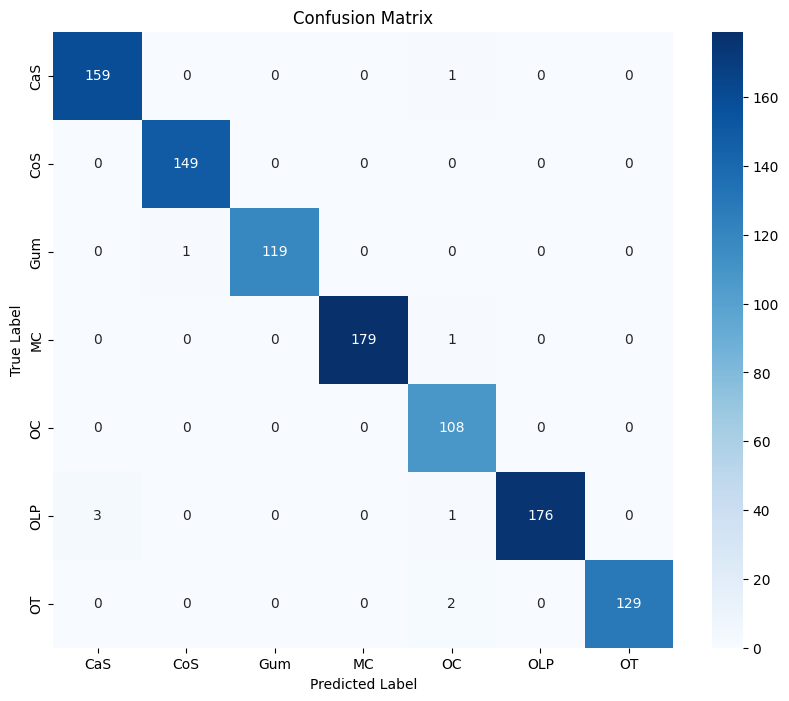

In [8]:
cm = confusion_matrix(test_labels, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

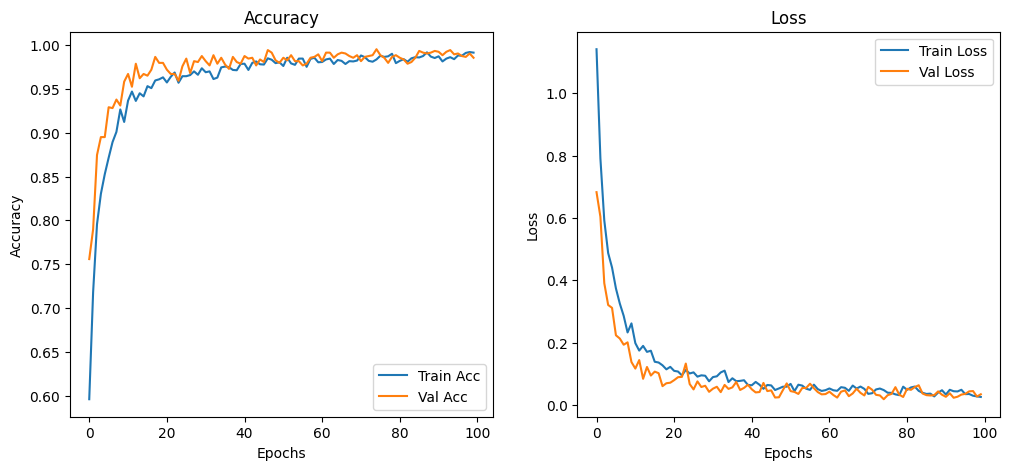

In [9]:
def plot_history(history):
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.title("Accuracy")

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Loss")

    plt.show()

plot_history(history)

In [10]:
print("\nEvaluating the model on the test dataset...")
test_loss, test_accuracy = model.evaluate(test_generator)

print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy:.4f}")


Evaluating the model on the test dataset...
33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9945 - loss: 0.0209

Final Test Loss: 0.0295
Final Test Accuracy: 0.9912
